# Customer Support Ticket RAG System — Milestone 1: Data Collection & Preprocessing

**Dataset:** `Tobi-Bueck/customer-support-tickets` from HuggingFace Hub (~61.8k rows, English + German).

**What this notebook covers:**
- Data loading & sanity checks
- Language column validation & English filtering
- Exploratory Data Analysis (class distribution, text lengths, tag analysis)
- Text cleaning with URL/email removal and Unicode normalization
- Lemmatization & domain-aware stopword removal
- Tokenization analysis using the target model's tokenizer
- Sentence embeddings generation (`all-MiniLM-L6-v2`)
- Embeddings visualization (PCA)
- Stratified train / validation / test split
- Export of all artifacts ready for Milestone 2


## 0. Setup & Imports

In [1]:
import os
import re
import unicodedata
import random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from scipy.stats import entropy as scipy_entropy

sns.set_theme(style="whitegrid")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

os.makedirs("data/processed", exist_ok=True)
print("Setup complete.")


Setup complete.


## 1. Data Loading

Pull the dataset straight from HuggingFace and convert to pandas.
Printing shape and dtypes first — column names changed between dataset versions
(`body` used to be `issue_description`) so confirming the schema before doing anything else.


In [2]:
dataset = load_dataset("Tobi-Bueck/customer-support-tickets")
df = dataset["train"].to_pandas()

print(f"Shape: {df.shape}")
print("\nColumn dtypes:")
print(df.dtypes)
print("\nSample rows:")
df.head(3)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/7.68k [00:00<?, ?B/s]

aa_dataset-tickets-multi-lang-5-2-50-ver(…):   0%|          | 0.00/26.0M [00:00<?, ?B/s]

(…)set-tickets-german_normalized_50_5_2.csv:   0%|          | 0.00/8.33M [00:00<?, ?B/s]

dataset-tickets-multi-lang-4-20k.csv:   0%|          | 0.00/18.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/61765 [00:00<?, ? examples/s]

Shape: (61765, 16)

Column dtypes:
subject      object
body         object
answer       object
type         object
queue        object
priority     object
language     object
version     float64
tag_1        object
tag_2        object
tag_3        object
tag_4        object
tag_5        object
tag_6        object
tag_7        object
tag_8        object
dtype: object

Sample rows:


,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte eine...",Vielen Dank für die Meldung des kritischen Sic...,Incident,Technical Support,high,de,51.0,Security,Outage,Disruption,Data Breach,None,None,None,None
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en,51.0,Account,Disruption,Outage,IT,Tech Support,None,None,None
2,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,en,51.0,Product,Feature,Tech Support,None,None,None,None,None


## 2. Language Validation & Filtering

The dataset mixes English and German tickets. Our pipeline is English-only
(`en_core_web_sm`, `all-MiniLM-L6-v2`), so we filter down to English.

Before trusting the `language` column blindly, we validate it on a 200-row sample
using `langdetect`. If accuracy is low, the filtering step would silently contaminate
the corpus with German text.


In [3]:
print("Language distribution:")
print(df["language"].value_counts())

try:
    from langdetect import detect, DetectorFactory
    DetectorFactory.seed = SEED

    def safe_detect(text):
        try:
            return detect(str(text))
        except Exception:
            return "unknown"

    sample = df.sample(200, random_state=SEED).copy()
    sample["detected"] = sample["body"].apply(safe_detect)
    accuracy = (sample["detected"] == sample["language"]).mean()
    print(f"\nLanguage column accuracy on 200-row sample: {accuracy:.1%}")

    mismatches = sample[sample["detected"] != sample["language"]]
    if len(mismatches):
        print(f"Mismatches ({len(mismatches)}):")
        print(mismatches[["body", "language", "detected"]].head(5))
    else:
        print("No mismatches — column is reliable.")

except ImportError:
    print("\nlangdetect not installed, skipping. pip install langdetect")

Language distribution:
language
de    33504
en    28261
Name: count, dtype: int64

langdetect not installed, skipping. pip install langdetect


In [4]:
df = df[df["language"] == "en"].reset_index(drop=True)
print(f"After English filter: {len(df):,} rows")

After English filter: 28,261 rows


## 3. Data Quality Checks

Null counts, full-row duplicates, and the key structural check:
does the same ticket body ever map to more than one queue label?
If it does, queue is noisy as a training target — better to know that here.


In [5]:
print("Null counts per column:")
print(df.isnull().sum())
print(f"\nFull-row duplicates: {df.duplicated().sum()}")

Null counts per column:
subject      3639
body            1
answer          6
type            0
queue           0
priority        0
language        0
version     11923
tag_1           0
tag_2          16
tag_3         113
tag_4        2584
tag_5       11960
tag_6       20353
tag_7       24562
tag_8       26653
dtype: int64

Full-row duplicates: 0


In [6]:
print(f"Unique body values: {df['body'].nunique():,} / Total rows: {len(df):,}")

dup_q = df.groupby("body")["queue"].nunique().sort_values(ascending=False)
print("\nBodies mapped to > 1 queue (top 10):")
print(dup_q[dup_q > 1].head(10))
print(f"\n{(dup_q == 1).mean():.1%} of bodies map to exactly one queue — queue is a clean label.")

Unique body values: 23,665 / Total rows: 28,261

Bodies mapped to > 1 queue (top 10):
body
Seeking Assistance                                     2
Could you provide details on securing medical data?    2
Could you provide more details?                        2
Assistance Required                                    2
Seek Assistance                                        2
In need of assistance                                  2
Seeking information                                    2
Offer insights into digital strategies                 2
Seeking assistance                                     2
Name: queue, dtype: int64

100.0% of bodies map to exactly one queue — queue is a clean label.


## 4. EDA — Class Distributions & Text Lengths

Queue distribution is the classification target for M2.
Class imbalance metrics will inform whether we need SMOTE or class weights.


Queue distribution:
queue
Technical Support                  8149
Product Support                    5305
Customer Service                   4269
IT Support                         3333
Billing and Payments               2897
Returns and Exchanges              1402
Service Outages and Maintenance    1106
Sales and Pre-Sales                 843
Human Resources                     553
General Inquiry                     404
Name: count, dtype: int64


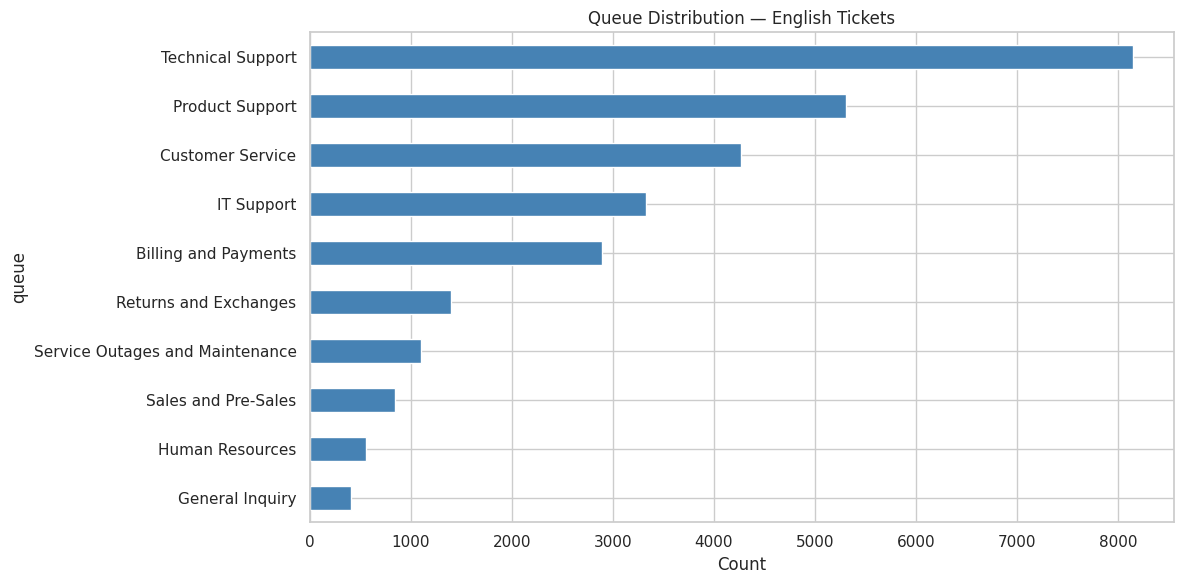

In [7]:
queue_counts = df["queue"].value_counts()
print("Queue distribution:")
print(queue_counts)

plt.figure(figsize=(12, 6))
queue_counts.plot(kind="barh", color="steelblue")
plt.title("Queue Distribution — English Tickets")
plt.xlabel("Count")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("data/processed/queue_distribution.png", dpi=100)
plt.show()

In [8]:
n_classes = len(queue_counts)
imbalance_ratio = queue_counts.max() / queue_counts.min()
cls_entropy = scipy_entropy(queue_counts, base=2)
max_entropy = np.log2(n_classes)

print("Class Imbalance Metrics")
print(f"  Classes:          {n_classes}")
print(f"  Imbalance ratio:  {imbalance_ratio:.1f}x  (max count / min count)")
print(f"  Class entropy:    {cls_entropy:.3f} / {max_entropy:.3f} bits")
print(f"  Balance score:    {cls_entropy / max_entropy:.1%}  (100% = perfectly balanced)")

if imbalance_ratio > 10:
    print("\n  M2 recommendation: Severe imbalance — use SMOTE or strong class weights.")
elif imbalance_ratio > 3:
    print("\n  M2 recommendation: Moderate imbalance — use class weights in loss function.")
else:
    print("\n  M2 recommendation: Mild imbalance — monitor per-class F1, may not need resampling.")

Class Imbalance Metrics
  Classes:          10
  Imbalance ratio:  20.2x  (max count / min count)
  Class entropy:    2.831 / 3.322 bits
  Balance score:    85.2%  (100% = perfectly balanced)

  M2 recommendation: Severe imbalance — use SMOTE or strong class weights.


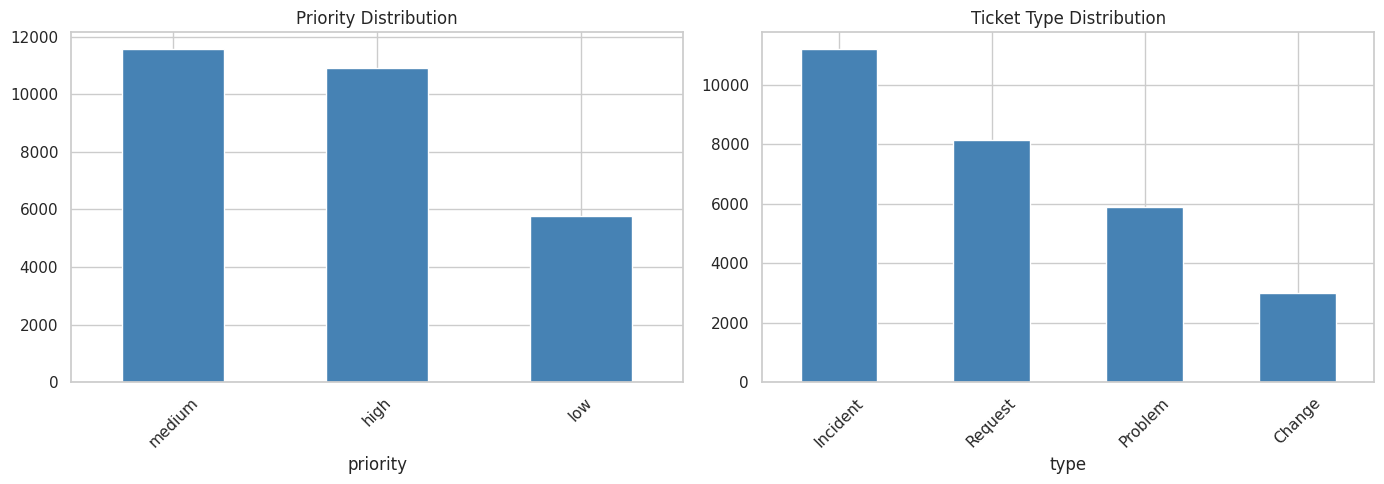

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df["priority"].value_counts().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Priority Distribution")
axes[0].tick_params(axis="x", rotation=45)

df["type"].value_counts().plot(kind="bar", ax=axes[1], color="steelblue")
axes[1].set_title("Ticket Type Distribution")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("data/processed/priority_type_distribution.png", dpi=100)
plt.show()

Body length (chars):
count    28260.0
mean       371.3
std        202.9
min          4.0
25%        203.0
50%        365.0
75%        533.0
max       1793.0
Name: body_length, dtype: float64

Answer length (chars):
count    28255.0
mean       372.7
std        178.4
min          4.0
25%        219.0
50%        372.0
75%        519.0
max       1315.0
Name: answer_length, dtype: float64


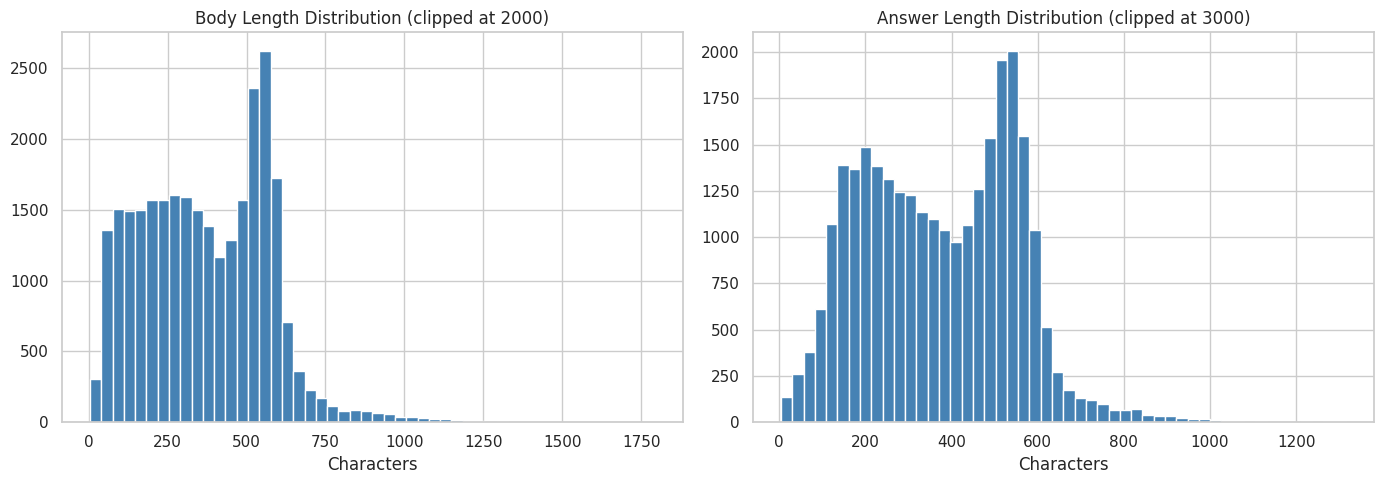


Very short bodies (< 50 chars):   593
Very long bodies  (> 3000 chars):  0


In [10]:
df["body_length"] = df["body"].str.len()
df["answer_length"] = df["answer"].str.len()

print("Body length (chars):")
print(df["body_length"].describe().round(1))
print("\nAnswer length (chars):")
print(df["answer_length"].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df["body_length"].clip(upper=2000).hist(bins=50, ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("Body Length Distribution (clipped at 2000)")
axes[0].set_xlabel("Characters")

df["answer_length"].clip(upper=3000).hist(bins=50, ax=axes[1], color="steelblue", edgecolor="white")
axes[1].set_title("Answer Length Distribution (clipped at 3000)")
axes[1].set_xlabel("Characters")

plt.tight_layout()
plt.savefig("data/processed/text_length_distribution.png", dpi=100)
plt.show()

print(f"\nVery short bodies (< 50 chars):   {(df['body_length'] < 50).sum()}")
print(f"Very long bodies  (> 3000 chars):  {(df['body_length'] > 3000).sum()}")

## 5. Text Cleaning

Cleaning pipeline applied to both `body` and `answer`:

1. **Unicode normalization (NFKC)** — handles smart quotes, em-dashes, accented chars
2. **Remove URLs and emails** — these turn into meaningless tokens without explicit removal
3. **Lowercase**
4. **Strip non-alphanumeric** — keep digits (error codes / version numbers carry signal)
5. **Collapse whitespace**

After cleaning we drop rows with extremely short or long bodies since they add
noise without adding signal.


In [11]:
def clean_text(text: str) -> str:
    """
    Normalize and clean raw ticket text.

    Steps:
      1. Unicode NFKC normalization
      2. HTML tag removal
      3. URL and email removal
      4. Lowercase
      5. Strip non-alphanumeric chars (digits kept intentionally)
      6. Collapse whitespace
    """
    text = str(text)
    text = unicodedata.normalize("NFKC", text)
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"\S+@\S+\.\S+", " ", text)
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


# Sanity check — print before/after for a few tickets
print("Before / After Cleaning")
for _, row in df.sample(3, random_state=SEED).iterrows():
    orig = str(row["body"])[:250]
    print(f"  Original:  {orig}")
    print(f"  Cleaned:   {clean_text(orig)}")
    print("  " + "-" * 70)


Before / After Cleaning
  Original:  Please request an update to the integration settings to ensure compatibility with various devices for the software project management workflows, to guarantee seamless operations.
  Cleaned:   please request an update to the integration settings to ensure compatibility with various devices for the software project management workflows to guarantee seamless operations
  ----------------------------------------------------------------------
  Original:  Insufficient encryption led to the data breach problem
  Cleaned:   insufficient encryption led to the data breach problem
  ----------------------------------------------------------------------
  Original:  The analytics data for the website have indicated a notable decrease in traffic last week. This could be due to recent algorithm changes or technical issues. Despite efforts to update SEO strategies and optimize loading times, the issue continues. I 
  Cleaned:   the analytics data for the website 

In [12]:
df["clean_body"] = df["body"].apply(clean_text)
df["clean_answer"] = df["answer"].apply(clean_text)

# Drop extreme body lengths
before = len(df)
df = df[
    (df["clean_body"].str.len() >= 30) &
    (df["clean_body"].str.len() <= 5000)
].reset_index(drop=True)

print(f"Rows removed (extreme body length): {before - len(df)}")
print(f"Rows remaining:                     {len(df):,}")


Rows removed (extreme body length): 148
Rows remaining:                     28,113


## 6. Lemmatization & Stopword Removal

Using spaCy `en_core_web_sm` to lemmatize and remove stopwords.
Applied on unique texts only — many tickets repeat the same phrasing, and
running the model on duplicates wastes time.

Domain-specific stopwords are added on top of spaCy's built-in list to filter
out high-frequency words that appear across all queues and carry no signal
(`support`, `please`, `team`, etc.).


In [13]:
import spacy

nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])

DOMAIN_STOPS = {
    "the", "a", "an", "i", "my", "to", "for", "in", "is", "was", "am",
    "not", "this", "there", "be", "with", "on", "and", "of", "you", "we",
    "our", "your", "have", "would", "could", "please", "dear", "support",
    "team", "customer", "help", "issue", "ticket", "request", "problem",
    "contact", "hi", "hello", "thank", "thanks", "use", "get", "let", "know",
}

unique_texts = df["clean_body"].unique()
print(f"Lemmatizing {len(unique_texts):,} unique texts...")

lemma_map = {}
for doc, text in zip(nlp.pipe(unique_texts, batch_size=256), unique_texts):
    tokens = [
        tok.lemma_
        for tok in doc
        if not tok.is_stop
        and tok.lemma_ not in DOMAIN_STOPS
        and len(tok.text) > 2
    ]
    lemma_map[text] = " ".join(tokens)

df["lemmatized_body"] = df["clean_body"].map(lemma_map)
print("Lemmatization done.")

print("\nLemmatization Examples")
for i in range(3):
    print(f"  clean:      {df['clean_body'].iloc[i][:110]}")
    print(f"  lemmatized: {df['lemmatized_body'].iloc[i][:110]}")
    print()


Lemmatizing 23,528 unique texts...
Lemmatization done.

Lemmatization Examples
  clean:      dear customer support team n ni am writing to report a significant problem with the centralized account manage
  lemmatized: write report significant centralized account management portal currently appear offline outage block access ac

  clean:      dear customer support team n ni hope this message reaches you well i am reaching out to request detailed infor
  lemmatized: hope message reach reach detailed information capability smart home integration product list website potential

  clean:      dear customer support team n ni hope this message finds you well i am reaching out to request clarification ab
  lemmatized: hope message find reach clarification billing payment procedure link account recently observe inconsistency ch



## 7. EDA — Keyword Analysis per Queue

Using `lemmatized_body` to pull the top keywords per queue.
Distinct vocabularies across queues = strong confirmation that `queue` is a meaningful label.


In [14]:
print("Top 5 keywords per queue")
print("=" * 65)
for queue in sorted(df["queue"].unique()):
    corpus = " ".join(df.loc[df["queue"] == queue, "lemmatized_body"].dropna())
    words = [w for w in corpus.split() if w not in DOMAIN_STOPS and len(w) > 2]
    top5 = Counter(words).most_common(5)
    kw = ", ".join(f"{w}({c})" for w, c in top5)
    print(f"  {queue:<30} {kw}")


Top 5 keywords per queue
  Billing and Payments           billing(1766), information(1548), provide(1474), payment(1443), appreciate(1289)
  Customer Service               datum(2005), provide(1855), appreciate(1702), information(1692), assistance(1483)
  General Inquiry                datum(225), investment(150), tool(143), strategy(137), update(134)
  Human Resources                datum(205), information(198), provide(195), software(189), system(184)
  IT Support                     update(1497), system(1324), software(1322), assistance(1191), datum(1157)
  Product Support                datum(2266), update(1947), assistance(1747), appreciate(1695), resolve(1653)
  Returns and Exchanges          datum(646), appreciate(529), provide(507), information(502), software(467)
  Sales and Pre-Sales            information(404), provide(395), datum(376), investment(289), appreciate(284)
  Service Outages and Maintenance service(658), system(519), outage(498), update(442), impact(420)
  Techni

## 8. EDA — Tag Analysis & Queue-Tag Cross Analysis

Tags are spread across `tag_1` through `tag_8`. Flattening all of them to get
the overall frequency, then building a heatmap of `queue × tag_1` to surface
any strong associations — useful for M2 if multi-label tag prediction gets explored.


Top 20 tags:
Tech Support     14371
IT               13984
Performance      11396
Feedback          8687
Documentation     7639
Bug               7515
Security          6557
Feature           5774
Disruption        4236
Outage            3587
Technical         3525
Network           3237
Product           2758
Sales             2601
Resolution        2404
Guidance          1987
Recovery          1768
Billing           1725
Crash             1722
Integration       1396
Name: count, dtype: int64


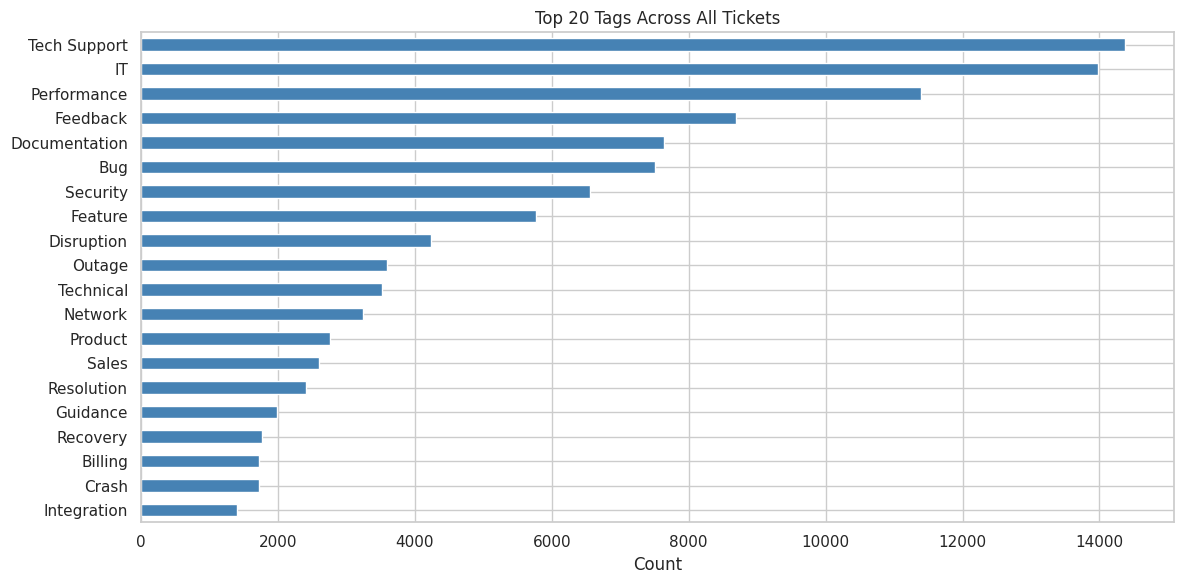

In [15]:
tag_cols = [c for c in df.columns if c.startswith("tag_")]
all_tags = pd.concat([df[c] for c in tag_cols]).dropna()
tag_counts = all_tags.value_counts().head(20)

print("Top 20 tags:")
print(tag_counts)

plt.figure(figsize=(12, 6))
tag_counts.plot(kind="barh", color="steelblue")
plt.title("Top 20 Tags Across All Tickets")
plt.xlabel("Count")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("data/processed/tag_distribution.png", dpi=100)
plt.show()


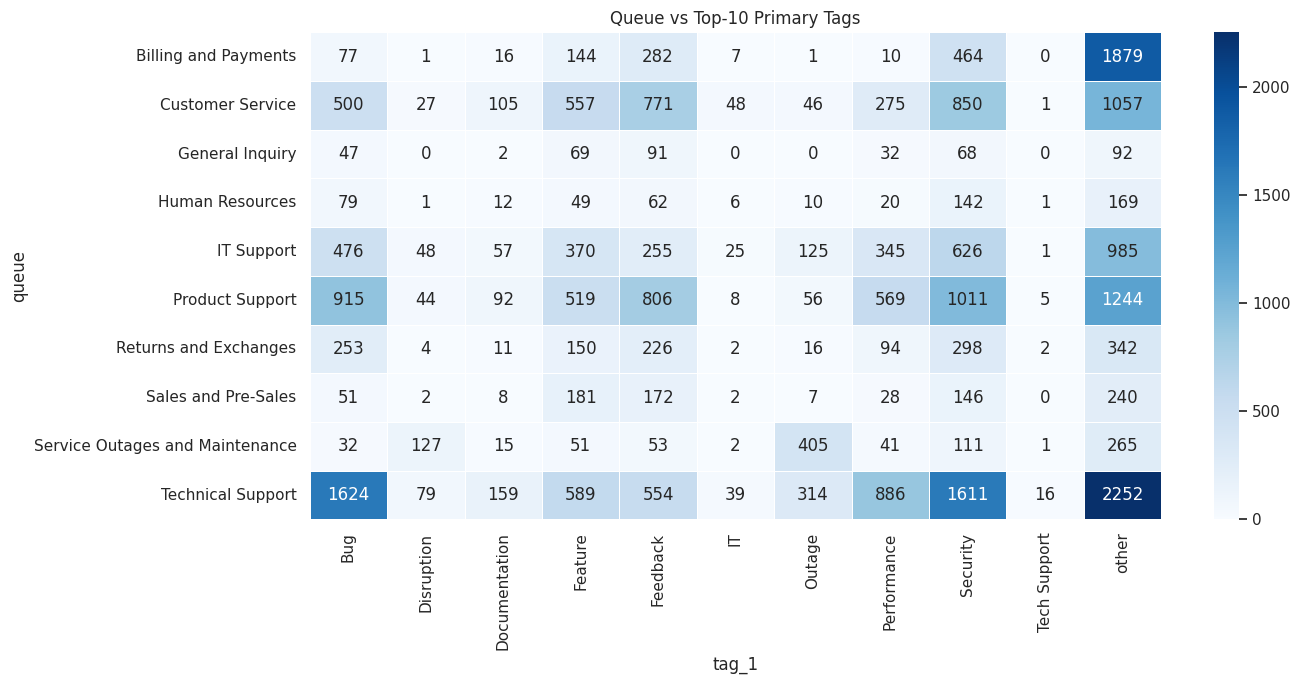

In [16]:
top_tags = tag_counts.head(10).index.tolist()
cross = pd.crosstab(
    df["queue"],
    df["tag_1"].where(df["tag_1"].isin(top_tags), other="other"),
)

plt.figure(figsize=(14, 7))
sns.heatmap(cross, annot=True, fmt="d", cmap="Blues", linewidths=0.4)
plt.title("Queue vs Top-10 Primary Tags")
plt.tight_layout()
plt.savefig("data/processed/queue_tag_heatmap.png", dpi=100)
plt.show()


## 9. Answer Quality Analysis

`answer` is the ground truth for BLEU scoring in M2.
Checking for empty answers after cleaning, template/repeated responses,
and overall length distribution — if answers are mostly template strings,
BLEU scores will be misleadingly high and won't reflect real generation quality.


In [17]:
df["clean_answer_length"] = df["clean_answer"].str.len()

print("Answer Quality Analysis")
print("\nClean answer length (chars):")
print(df["clean_answer_length"].describe().round(1))

empty = (df["clean_answer"].str.strip() == "").sum()
print(f"\nEmpty answers after cleaning: {empty}")

answer_vc = df["clean_answer"].value_counts()
template_count = (answer_vc > 5).sum()
print(f"\nUnique answers:                          {len(answer_vc):,}")
print(f"Answers appearing > 5 times (templates): {template_count}")
print(f"Template share:                          {template_count / len(answer_vc):.1%}")

print("\nTop 3 most repeated answers:")
for ans, cnt in answer_vc.head(3).items():
    print(f"  [{cnt}x] {str(ans)[:100]}...")


Answer Quality Analysis

Clean answer length (chars):
count    28113.0
mean       365.9
std        174.6
min          4.0
25%        216.0
50%        364.0
75%        509.0
max       1289.0
Name: clean_answer_length, dtype: float64

Empty answers after cleaning: 0

Unique answers:                          23,456
Answers appearing > 5 times (templates): 1
Template share:                          0.0%

Top 3 most repeated answers:
  [6x] none...
  [4x] we will get back to you soon...
  [4x] we will contact you shortly...


## 10. Tokenization Analysis

Checking actual token counts using `all-MiniLM-L6-v2`'s tokenizer — not a proxy like
word count or character count. The model has a 512-token hard limit; anything over
that gets silently truncated. Important to quantify how much content is lost.


config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Tokenization Analysis  (sample n=5,000)
count    5000.0
mean       62.9
std        33.5
min         5.0
25%        36.0
50%        63.0
75%        88.0
max       265.0
Name: clean_body, dtype: float64

Tickets > 512 tokens (will be truncated): 0  (0.0%)
  → Truncation is minimal — standard encoding is fine.


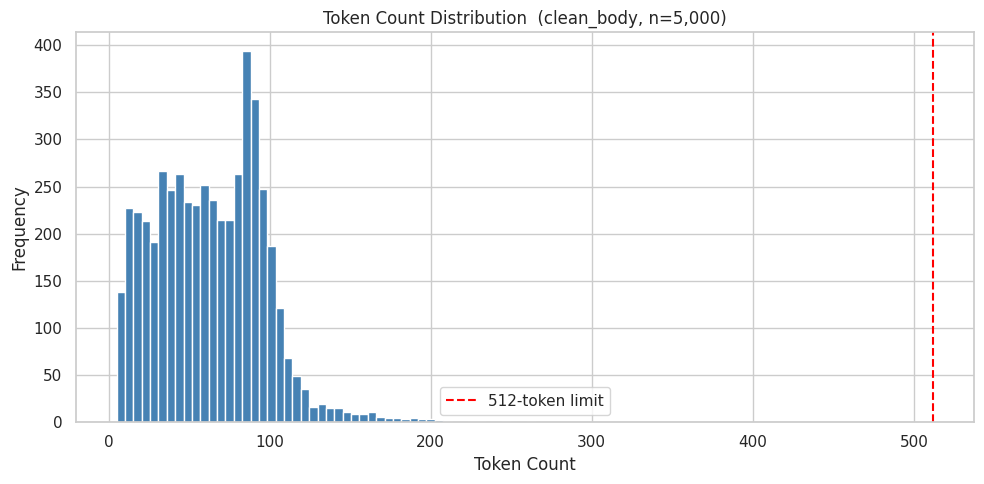

In [18]:
from transformers import AutoTokenizer

MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

sample_n = min(5000, len(df))
sample_df = df.sample(sample_n, random_state=SEED)

token_counts = sample_df["clean_body"].apply(
    lambda x: len(tokenizer.encode(x, add_special_tokens=True, truncation=False))
)

print(f"Tokenization Analysis  (sample n={sample_n:,})")
print(token_counts.describe().round(1))

over_limit = (token_counts > 512).sum()
pct = over_limit / sample_n
print(f"\nTickets > 512 tokens (will be truncated): {over_limit}  ({pct:.1%})")
if pct > 0.10:
    print("  → Notable truncation — consider mean-pooling on chunks in M2.")
else:
    print("  → Truncation is minimal — standard encoding is fine.")

plt.figure(figsize=(10, 5))
token_counts.clip(upper=600).hist(bins=50, color="steelblue", edgecolor="white")
plt.axvline(512, color="red", linestyle="--", linewidth=1.5, label="512-token limit")
plt.title(f"Token Count Distribution  (clean_body, n={sample_n:,})")
plt.xlabel("Token Count")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.savefig("data/processed/token_count_distribution.png", dpi=100)
plt.show()


## 11. Sentence Embeddings Generation

Generating 384-dimensional sentence embeddings using `all-MiniLM-L6-v2`.
Embeddings are L2-normalized — cosine similarity between any two vectors
reduces to a dot product, which is what FAISS and Azure Cognitive Search
expect by default.

**Output:** `data/processed/body_embeddings.npy`  shape: `(N, 384)`, dtype: `float32`


In [26]:
# import sys
# !{sys.executable} -m pip install sentence-transformers

In [20]:
from sentence_transformers import SentenceTransformer

print("Loading all-MiniLM-L6-v2 ...")
emb_model = SentenceTransformer("all-MiniLM-L6-v2")

texts = df["clean_body"].tolist()
print(f"Encoding {len(texts):,} tickets ...")

body_embeddings = emb_model.encode(
    texts,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True,   # L2 normalize for cosine similarity
)

print(f"\nShape:  {body_embeddings.shape}")
print(f"Dtype:  {body_embeddings.dtype}")
print(f"Norm check (first vector): {np.linalg.norm(body_embeddings[0]):.6f}  (should be 1.0)")

np.save("data/processed/body_embeddings.npy", body_embeddings)
print("\nSaved: data/processed/body_embeddings.npy")

Loading all-MiniLM-L6-v2 ...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Encoding 28,113 tickets ...


Batches:   0%|          | 0/440 [00:00<?, ?it/s]


Shape:  (28113, 384)
Dtype:  float32
Norm check (first vector): 1.000000  (should be 1.0)

Saved → data/processed/body_embeddings.npy


## 12. Embeddings Visualization (PCA)

Projecting the 384-dim embeddings to 2D via PCA to visually inspect cluster quality.
If queue clusters are roughly separable here, that's a good signal that the
embeddings will support effective retrieval and classification in M2.


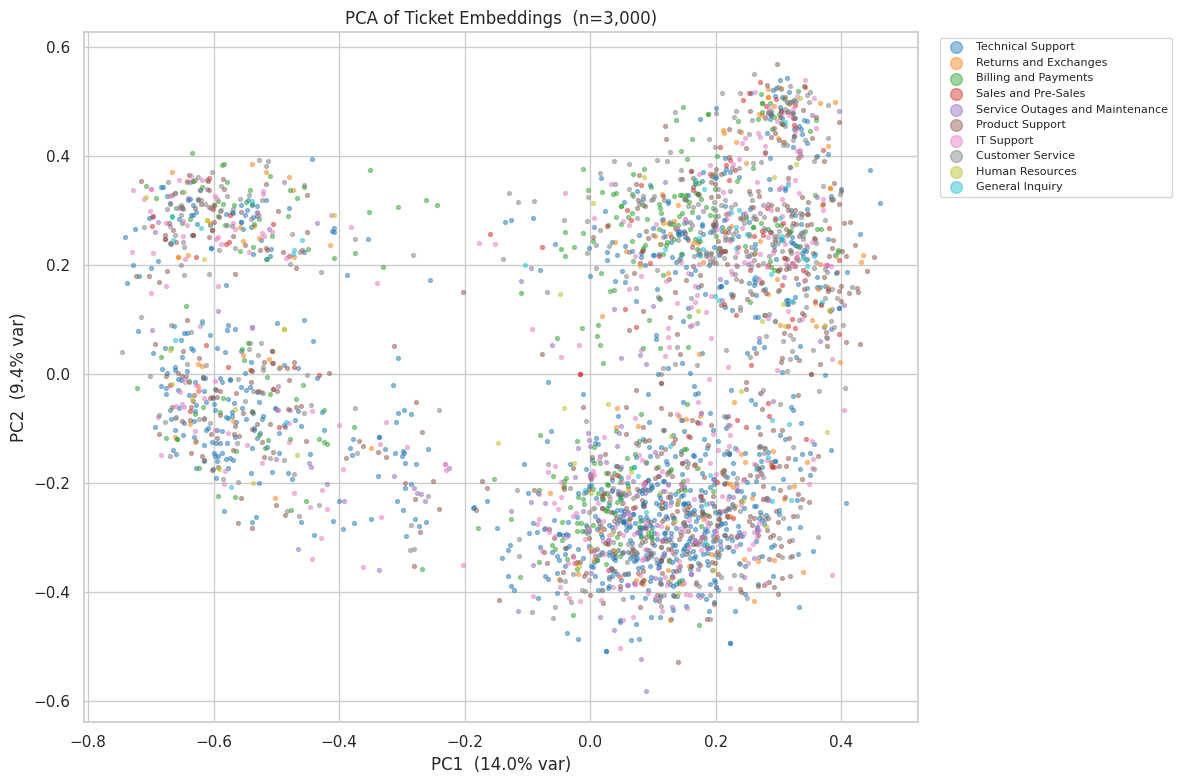

In [21]:
from sklearn.decomposition import PCA

viz_n = min(3000, len(df))
rng = np.random.default_rng(SEED)
idx = rng.choice(len(df), viz_n, replace=False)

pca = PCA(n_components=2, random_state=SEED)
coords = pca.fit_transform(body_embeddings[idx])
viz_labels = df["queue"].iloc[idx].values

queues = df["queue"].unique()
palette = sns.color_palette("tab10", len(queues))

plt.figure(figsize=(12, 8))
for q, color in zip(queues, palette):
    mask = viz_labels == q
    plt.scatter(coords[mask, 0], coords[mask, 1],
                label=q, alpha=0.45, s=8, color=color)

plt.title(f"PCA of Ticket Embeddings  (n={viz_n:,})")
plt.xlabel(f"PC1  ({pca.explained_variance_ratio_[0]:.1%} var)")
plt.ylabel(f"PC2  ({pca.explained_variance_ratio_[1]:.1%} var)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8, markerscale=3)
plt.tight_layout()
plt.savefig("data/processed/embeddings_pca.png", dpi=100, bbox_inches="tight")
plt.show()


## 13. Train / Validation / Test Split

Stratified 70 / 15 / 15 split preserving queue distribution across all three sets.
Embeddings are sliced in sync with the DataFrames so M2 can load them directly
without re-running the embedding step.


In [22]:
# Stratified 70/15/15
train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df["queue"], random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["queue"], random_state=SEED
)

# Slice embeddings BEFORE resetting indices
train_emb = body_embeddings[train_df.index]
val_emb   = body_embeddings[val_df.index]
test_emb  = body_embeddings[test_df.index]

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f"Train:       {len(train_df):,}  ({len(train_df)/len(df):.0%})")
print(f"Validation:  {len(val_df):,}  ({len(val_df)/len(df):.0%})")
print(f"Test:        {len(test_df):,}  ({len(test_df)/len(df):.0%})")

print("\nQueue distribution across splits (proportions):")
cmp = pd.DataFrame({
    "train": train_df["queue"].value_counts(normalize=True),
    "val":   val_df["queue"].value_counts(normalize=True),
    "test":  test_df["queue"].value_counts(normalize=True),
}).round(3)
print(cmp.to_string())


Train:       19,679  (70%)
Validation:  4,217  (15%)
Test:        4,217  (15%)

Queue distribution across splits (proportions):
                                 train    val   test
queue                                               
Technical Support                0.289  0.289  0.289
Product Support                  0.187  0.187  0.188
Customer Service                 0.151  0.151  0.151
IT Support                       0.118  0.118  0.118
Billing and Payments             0.102  0.102  0.102
Returns and Exchanges            0.050  0.050  0.050
Service Outages and Maintenance  0.039  0.039  0.039
Sales and Pre-Sales              0.030  0.030  0.030
Human Resources                  0.020  0.020  0.019
General Inquiry                  0.014  0.014  0.014


In [23]:
train_df.to_csv("data/processed/train.csv", index=False)
val_df.to_csv("data/processed/val.csv",     index=False)
test_df.to_csv("data/processed/test.csv",   index=False)

np.save("data/processed/train_embeddings.npy", train_emb)
np.save("data/processed/val_embeddings.npy",   val_emb)
np.save("data/processed/test_embeddings.npy",  test_emb)

print("Saved:")
print("  data/processed/train.csv + train_embeddings.npy")
print("  data/processed/val.csv   + val_embeddings.npy")
print("  data/processed/test.csv  + test_embeddings.npy")


Saved:
  data/processed/train.csv + train_embeddings.npy
  data/processed/val.csv   + val_embeddings.npy
  data/processed/test.csv  + test_embeddings.npy


## 14. Export Full Cleaned Corpus

In [24]:
# Build column list — include optional columns only if they exist in the dataset
keep_cols = ["body", "answer", "type", "queue", "priority"]
for opt in ["subject", "version"]:
    if opt in df.columns:
        keep_cols.insert(0, opt)

keep_cols += [c for c in tag_cols if c in df.columns]
keep_cols += [
    "clean_body", "clean_answer", "lemmatized_body",
    "body_length", "answer_length", "clean_answer_length",
]

df[keep_cols].to_csv("data/processed/cleaned_corpus.csv", index=False)
print(f"Saved cleaned_corpus.csv: {df[keep_cols].shape}")


Saved cleaned_corpus.csv: (28113, 21)


## 15. Milestone 1 — Deliverables Summary

In [25]:
print("=" * 65)
print("  MILESTONE 1 DELIVERABLES")
print("=" * 65)

deliverables = [
    ("data/processed/cleaned_corpus.csv",            "Full cleaned corpus"),
    ("data/processed/train.csv",                     "Train split  (70%)"),
    ("data/processed/val.csv",                       "Validation split  (15%)"),
    ("data/processed/test.csv",                      "Test split  (15%)"),
    ("data/processed/body_embeddings.npy",           "Full embeddings  (384-dim)"),
    ("data/processed/train_embeddings.npy",          "Train embeddings"),
    ("data/processed/val_embeddings.npy",            "Val embeddings"),
    ("data/processed/test_embeddings.npy",           "Test embeddings"),
    ("data/processed/queue_distribution.png",        "Queue distribution plot"),
    ("data/processed/priority_type_distribution.png","Priority/type plot"),
    ("data/processed/text_length_distribution.png",  "Text length plot"),
    ("data/processed/tag_distribution.png",          "Tag distribution plot"),
    ("data/processed/queue_tag_heatmap.png",         "Queue-tag heatmap"),
    ("data/processed/token_count_distribution.png",  "Token count plot"),
    ("data/processed/embeddings_pca.png",            "Embeddings PCA plot"),
]

all_ok = True
for path, desc in deliverables:
    exists = os.path.exists(path)
    if not exists:
        all_ok = False
    mark = "OK" if exists else "MISSING"
    size = f"{os.path.getsize(path)/1024:.0f} KB" if exists else "—"
    print(f"  [{mark}]  {desc:<40} {size:>8}   {path}")

print("\n" + ("All deliverables present." if all_ok else "WARNING: some files are missing."))


  MILESTONE 1 DELIVERABLES
  [OK]  Full cleaned corpus                      50980 KB   data/processed/cleaned_corpus.csv
  [OK]  Train split  (70%)                       35703 KB   data/processed/train.csv
  [OK]  Validation split  (15%)                   7732 KB   data/processed/val.csv
  [OK]  Test split  (15%)                         7627 KB   data/processed/test.csv
  [OK]  Full embeddings  (384-dim)               42170 KB   data/processed/body_embeddings.npy
  [OK]  Train embeddings                         29519 KB   data/processed/train_embeddings.npy
  [OK]  Val embeddings                            6326 KB   data/processed/val_embeddings.npy
  [OK]  Test embeddings                           6326 KB   data/processed/test_embeddings.npy
  [OK]  Queue distribution plot                     45 KB   data/processed/queue_distribution.png
  [OK]  Priority/type plot                          39 KB   data/processed/priority_type_distribution.png
  [OK]  Text length plot                   